# Heart Disease Prediction using Supervised Machine Learning
**Name:** Faisal Khan | **Enrollment No.:** 202510116100093 | **Section:** B

## 1. Importing Required Libraries
We import the core libraries needed for data handling (pandas, numpy) and visualization (matplotlib, seaborn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Problem Statement
Cardiovascular disease is one of the leading causes of death worldwide. Early detection can significantly improve treatment outcomes. The goal of this project is to build a supervised machine learning classification model that predicts whether a patient has heart disease, based on clinical attributes such as age, blood pressure, cholesterol level, chest pain type, and other diagnostic measurements.

This is a binary classification problem: the target variable Heart Disease indicates Presence (patient has heart disease) or Absence (patient does not have heart disease).

## 3. Dataset Description
- Dataset: Heart Disease Prediction Dataset
- Records: 270 patients
- Features: 13 clinical/diagnostic input features + 1 target column (Heart Disease)
- Source: Kaggle (derived from the UCI Heart Disease - Cleveland database)

## 4. Loading the Dataset
We load the dataset using pandas.read_csv() and inspect its first few rows and shape to confirm it has loaded correctly.

In [2]:
df = pd.read_csv('Heart_Disease_Prediction_Data.csv')

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.shape


(270, 14)

## 5. Data Preprocessing
Before training any model, we check the dataset for data quality issues - missing values, duplicate records, and the format of the target column - and fix them as needed.

### 5.1 Checking for Missing Values

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Total missing values: 0


### 5.2 Checking for Duplicate Rows

In [6]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [7]:
# Check unique values in target column
print(df['Heart Disease'].unique())
print(df['Heart Disease'].value_counts())

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str
Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


### 5.3 Encoding the Target Column
The target column Heart Disease currently contains text values (Presence / Absence). Machine learning models require numeric input, so we first check the unique values present and then encode them: Presence to 1, Absence to 0.

In [8]:
# Encoding: Presence = 1, Absence = 0
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

print(df['Heart Disease'].value_counts())
df.head()

Heart Disease
0    150
1    120
Name: count, dtype: int64


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


## 6. Exploratory Data Analysis (EDA)
We now visualize the dataset to understand the distribution of the target classes, the spread of key features like age, and how features relate to each other and to the target.

### 6.1 Target Class Distribution

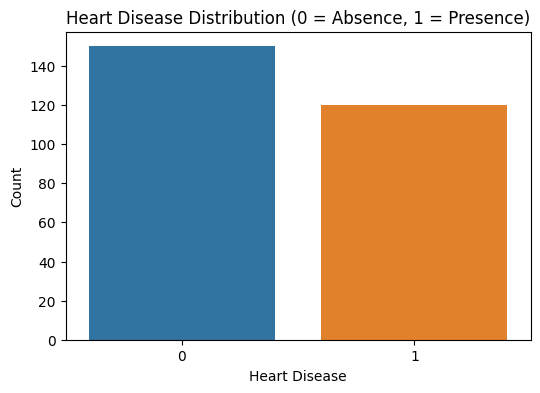

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Heart Disease', hue='Heart Disease', data=df, legend=False)
plt.title('Heart Disease Distribution (0 = Absence, 1 = Presence)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

### 6.2 Age Distribution
Checking the spread of patient ages helps confirm the dataset covers a realistic and relevant age range for heart disease risk.

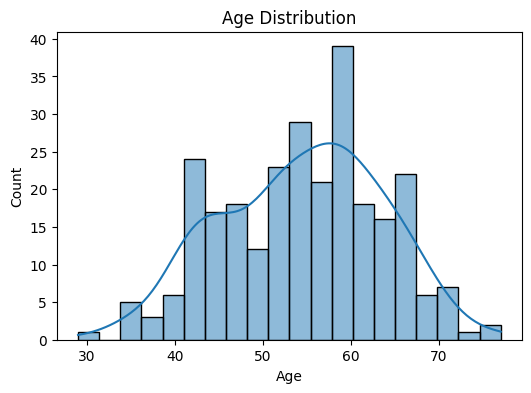

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution')
plt.show()

### 6.3 Feature Correlation Heatmap
The heatmap below shows how strongly each feature is correlated with every other feature, including the target variable. Features with stronger correlation to Heart Disease are likely to be more useful predictors.

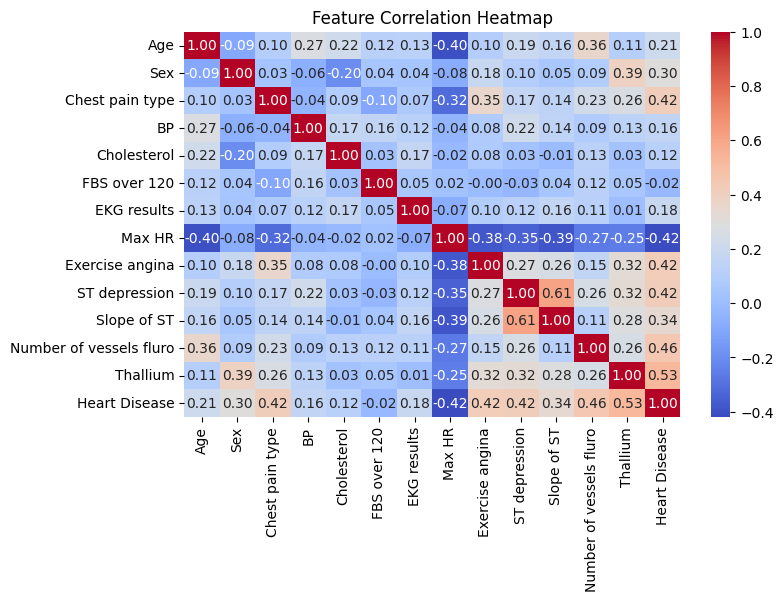

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 7. Feature-Target Split, Train-Test Split, and Scaling

### 7.1 Splitting Features (X) and Target (y)
We separate the input features from the target column we want to predict.

In [12]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (270, 13)
y shape: (270,)


### 7.2 Train-Test Split
We split the data into 80% training data and 20% testing data. stratify=y ensures the proportion of Presence/Absence cases is preserved in both the training and test sets.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (216, 13)
Test shape: (54, 13)


### 7.3 Feature Scaling
Algorithms like Logistic Regression and SVM are sensitive to the scale of input values, so we standardize all features to have zero mean and unit variance using StandardScaler. Important: the scaler is fit only on training data and then applied to the test data, to avoid data leakage.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print(X_train_scaled[0])  # sample check

Scaling done.
[-1.3361797  -1.47528661 -0.10435568 -0.63795169 -0.76298149 -0.39380225
 -1.05474207  1.00746877 -0.68511879 -0.93924147  0.69812296 -0.70900762
 -0.85615942]


## 8. Model Development
To get a reliable comparison rather than relying on a single algorithm, we train three different supervised classification models:

1. Logistic Regression - a simple, interpretable linear baseline model
2. Support Vector Machine (SVM) - with an RBF kernel to capture non-linear patterns
3. Random Forest - an ensemble of decision trees, robust to noise and overfitting

### 8.1 Defining the Models

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

### 8.2 Training Process
Each model is trained on the same scaled training data using a fixed random_state=42 for reproducibility.

In [16]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
SVM trained successfully.
Random Forest trained successfully.


## 9. Model Evaluation
Since this is a classification problem, we evaluate each model using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix - the metrics specified for classification tasks.

### 9.1 Computing Evaluation Metrics for Each Model

In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'cm': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred
    }
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1-Score:  {results[name]['f1']:.4f}")
    print("Confusion Matrix:\n", results[name]['cm'])


=== Logistic Regression ===
Accuracy:  0.8519
Precision: 0.7857
Recall:    0.9167
F1-Score:  0.8462
Confusion Matrix:
 [[24  6]
 [ 2 22]]

=== SVM ===
Accuracy:  0.8148
Precision: 0.7692
Recall:    0.8333
F1-Score:  0.8000
Confusion Matrix:
 [[24  6]
 [ 4 20]]

=== Random Forest ===
Accuracy:  0.8148
Precision: 0.7692
Recall:    0.8333
F1-Score:  0.8000
Confusion Matrix:
 [[24  6]
 [ 4 20]]


### 9.2 Detailed Classification Report

In [18]:
for name, model in trained_models.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, results[name]['y_pred']))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


=== SVM ===
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted 

### 9.3 Visualizing Confusion Matrices

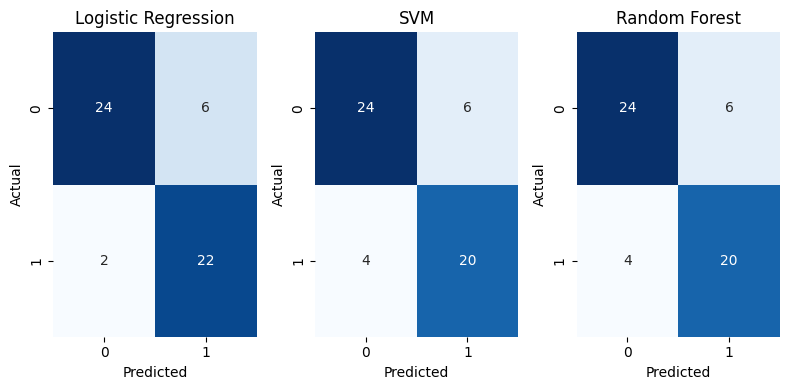

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(8,4))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [20]:
comparison_df = pd.DataFrame({
    name: [res['accuracy'], res['precision'], res['recall'], res['f1']]
    for name, res in results.items()
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

comparison_df

,Logistic Regression,SVM,Random Forest
Accuracy,0.851852,0.814815,0.814815
Precision,0.785714,0.769231,0.769231
Recall,0.916667,0.833333,0.833333
F1-Score,0.846154,0.800000,0.800000


### 9.4 Comparing Model Performance

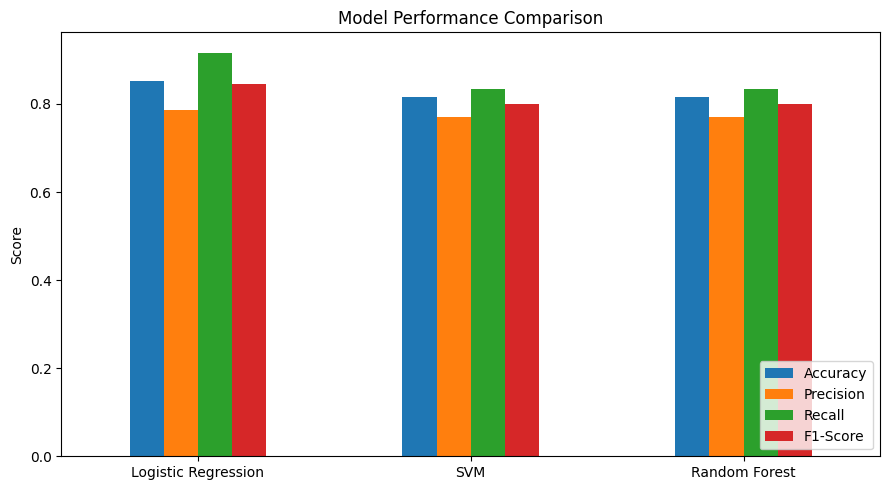

In [21]:
comparison_df.T.plot(kind='bar', figsize=(9,5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Saving Trained Models

In [23]:

import joblib

# Saving each trained model as a .pkl file
joblib.dump(trained_models['Logistic Regression'], 'logistic_regression_model.pkl')
joblib.dump(trained_models['SVM'], 'svm_model.pkl')
joblib.dump(trained_models['Random Forest'], 'random_forest_model.pkl')

# Also save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("All models saved successfully as .pkl files!")

All models saved successfully as .pkl files!
